# TinyStories Experiment Analysis

This notebook analyzes outputs from `run_tinystories_experiments.py`, especially:
- `events.jsonl` (timestep history)
- `run_summary.json` (per-run summary)

Default location is `./finetune_runs_large/history/`.

In [33]:
import json
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")

In [34]:
import spacy
from collections import Counter



In [35]:
# Point this to your experiment output root
OUTPUT_ROOT = Path("./finetune_runs_Tim")
HISTORY_DIR = OUTPUT_ROOT / "history"
EVENTS_PATH = HISTORY_DIR / "events.jsonl"
SUMMARY_PATH = HISTORY_DIR / "run_summary.json"

print("History dir:", HISTORY_DIR.resolve())
print("events.jsonl exists:", EVENTS_PATH.exists())
print("run_summary.json exists:", SUMMARY_PATH.exists())

History dir: /workspace/tinystoriesFT/finetune_runs_Tim/history
events.jsonl exists: True
run_summary.json exists: True


In [36]:
def load_events_jsonl(path: Path):
    rows = []
    if not path.exists():
        return pd.DataFrame()
    with path.open("r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            rows.append(json.loads(line))
    return pd.DataFrame(rows)

def load_run_summary(path: Path):
    if not path.exists():
        return {}
    with path.open("r", encoding="utf-8") as f:
        return json.load(f)

In [37]:
events_df = load_events_jsonl(EVENTS_PATH)
summary = load_run_summary(SUMMARY_PATH)

print("Events rows:", len(events_df))
print("Summary keys:", list(summary.keys()))

if len(events_df):
    display(events_df.head())

Events rows: 84
Summary keys: ['completed_at', 'config', 'run_summaries', 'timestep_history_index']


,time,event,config,run,fraction,run_steps,eval_steps,dataset_size,special_count,non_animal_count,...,eval_loss,eval_runtime,final_model_path,switched_acc_before_cont,switched_acc_after_cont,switched_loss_before_cont,switched_loss_after_cont,switched_ppl_before_cont,switched_ppl_after_cont,summary_file
0,2026-03-05T16:02:05Z,run_start,"{'model_id': 'SauravP97/tiny-stories-3M', 'tok...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2026-03-05T16:04:04Z,run_init,NaN,special_frac_0_1,0.1,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2026-03-05T16:04:35Z,train_start,NaN,special_frac_0_1,0.1,6250.0,1562.0,100000.0,10000.0,90000.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2026-03-05T16:06:20Z,timestep_eval,NaN,special_frac_0_1,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2026-03-05T16:08:03Z,timestep_eval,NaN,special_frac_0_1,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [38]:
run_summaries_df = pd.DataFrame(summary.get("run_summaries", []))

if run_summaries_df.empty:
    print("No run summaries found yet.")
else:
    cols = [c for c in [
        "run", "fraction", "special_count", "non_animal_count",
        "dataset_size", "actual_fraction", "run_steps", "eval_steps",
        "eval_loss", "eval_runtime"
    ] if c in run_summaries_df.columns]
    display(run_summaries_df[cols].sort_values("fraction"))

,run,fraction,special_count,non_animal_count,dataset_size,actual_fraction,run_steps,eval_steps,eval_loss,eval_runtime
0,special_frac_0_5,0.5,200000,200000,400000,0.5,25000,6250,2.150774,0.3504
1,special_frac_1,1.0,200000,0,200000,1.0,12500,3125,2.239141,0.2884


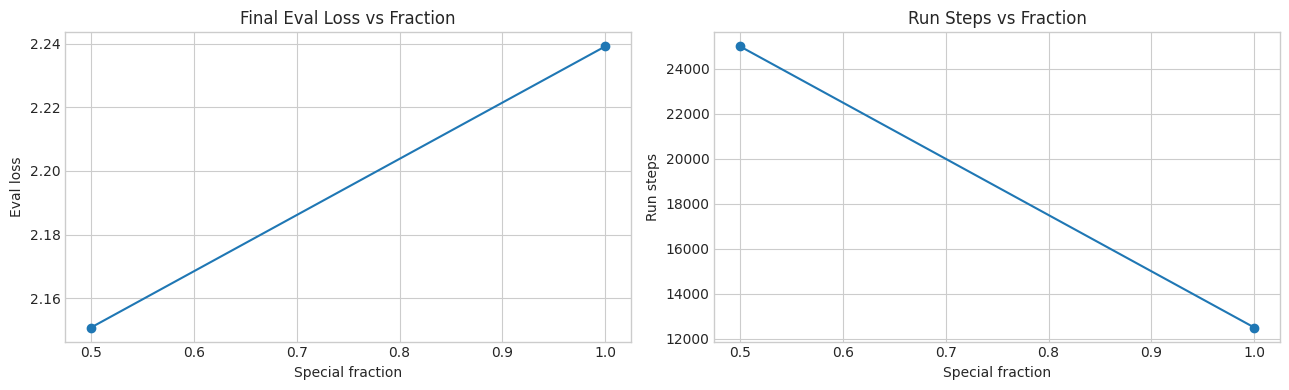

In [39]:
# Plot endpoint metrics by fraction
if run_summaries_df.empty:
    print("No summary data to plot.")
else:
    plot_df = run_summaries_df.sort_values("fraction").copy()

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    axes[0].plot(plot_df["fraction"], plot_df["eval_loss"], marker="o")
    axes[0].set_title("Final Eval Loss vs Fraction")
    axes[0].set_xlabel("Special fraction")
    axes[0].set_ylabel("Eval loss")

    if "run_steps" in plot_df.columns:
        axes[1].plot(plot_df["fraction"], plot_df["run_steps"], marker="o")
        axes[1].set_ylabel("Run steps")
        axes[1].set_title("Run Steps vs Fraction")
    else:
        axes[1].plot(plot_df["fraction"], plot_df["dataset_size"], marker="o")
        axes[1].set_ylabel("Dataset size")
        axes[1].set_title("Dataset Size vs Fraction")

    axes[1].set_xlabel("Special fraction")
    plt.tight_layout()
    plt.show()

,time,event,config,run,fraction,run_steps,eval_steps,dataset_size,special_count,non_animal_count,...,eval_loss,eval_runtime,final_model_path,switched_acc_before_cont,switched_acc_after_cont,switched_loss_before_cont,switched_loss_after_cont,switched_ppl_before_cont,switched_ppl_after_cont,summary_file
3,2026-03-05T16:06:20Z,timestep_eval,NaN,special_frac_0_1,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2026-03-05T16:08:03Z,timestep_eval,NaN,special_frac_0_1,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,2026-03-05T16:09:47Z,timestep_eval,NaN,special_frac_0_1,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,2026-03-05T16:11:31Z,timestep_eval,NaN,special_frac_0_1,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,2026-03-05T16:11:36Z,timestep_eval,NaN,special_frac_0_1,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
33,2026-03-05T16:39:51Z,timestep_eval,NaN,special_frac_0_1,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
34,2026-03-05T16:49:16Z,timestep_eval,NaN,special_frac_0_1,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
35,2026-03-05T16:57:40Z,timestep_eval,NaN,special_frac_0_1,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
36,2026-03-05T17:06:04Z,timestep_eval,NaN,special_frac_0_1,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
37,2026-03-05T17:06:10Z,timestep_eval,NaN,special_frac_0_1,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


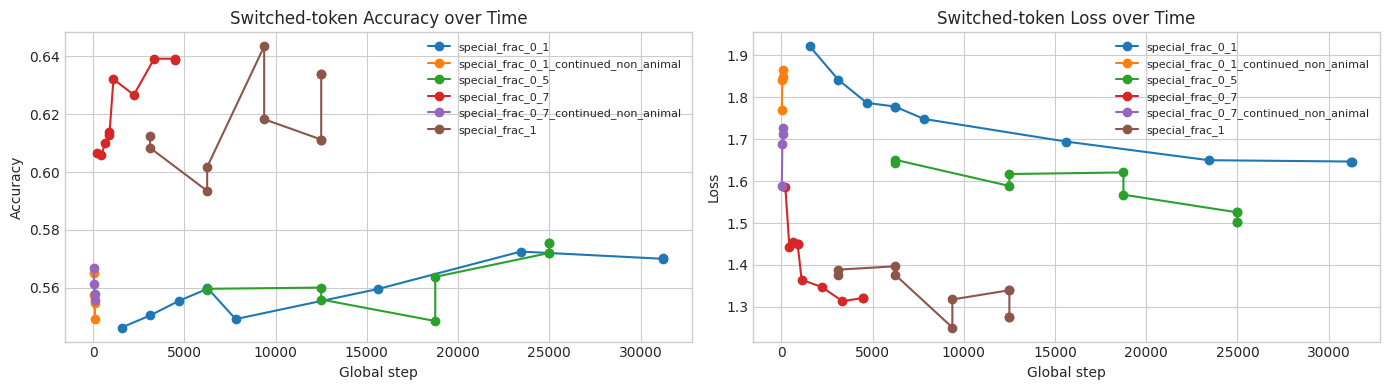

In [40]:
# Timestep switched-token metrics
if events_df.empty:
    print("No event history found.")
else:
    ts = events_df[events_df.get("event", "") == "timestep_eval"].copy()
    if ts.empty:
        print("No timestep_eval rows found in history.")
    else:
        ts["global_step"] = pd.to_numeric(ts["global_step"], errors="coerce")
        ts["switched_acc"] = pd.to_numeric(ts["switched_acc"], errors="coerce")
        ts["switched_loss"] = pd.to_numeric(ts["switched_loss"], errors="coerce")

        display(ts.sort_values(["run", "global_step"]).head(20))

        fig, axes = plt.subplots(1, 2, figsize=(14, 4))

        for run_name, g in ts.groupby("run"):
            g = g.sort_values("global_step")
            axes[0].plot(g["global_step"], g["switched_acc"], marker="o", label=run_name)
            axes[1].plot(g["global_step"], g["switched_loss"], marker="o", label=run_name)

        axes[0].set_title("Switched-token Accuracy over Time")
        axes[0].set_xlabel("Global step")
        axes[0].set_ylabel("Accuracy")

        axes[1].set_title("Switched-token Loss over Time")
        axes[1].set_xlabel("Global step")
        axes[1].set_ylabel("Loss")

        axes[0].legend(fontsize=8)
        axes[1].legend(fontsize=8)
        plt.tight_layout()
        plt.show()

In [48]:
# Check: switched-token accuracy on pretrained model (same metric as training)
import torch
from datasets import load_dataset
from transformers import AutoTokenizer
from tinystories_utils import (
    build_name_vocabulary,
    replace_most_common_name_with_tim,
    eval_switched_positions_quick,
    load_causal_lm_compat,
    RunConfig,
 )

cfg = RunConfig()
dataset_id = cfg.dataset_id
model_id = cfg.model_id
fallback_tok_id = cfg.tokenizer_fallback_id
n_eval = cfg.switched_eval_samples

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)
print("Model:", model_id)
print("Switched eval samples target:", n_eval)

# Reuse loaded train split/name vocab when available to keep notebook fast
if "train_full" in globals() and train_full is not None:
    train_split = train_full
else:
    train_split = load_dataset(dataset_id, split="train")

if "name_vocab" in globals() and isinstance(name_vocab, dict) and len(name_vocab) > 0:
    allowed_names = name_vocab
else:
    allowed_names = build_name_vocabulary(train_split, min_count=1)

val_full = load_dataset(dataset_id, split="validation")
eval_pairs = []
for ex in val_full:
    text = ex["text"]
    transformed, spans = replace_most_common_name_with_tim(text, allowed_names)
    if spans:
        eval_pairs.append((transformed, spans))
    if len(eval_pairs) >= n_eval:
        break

if len(eval_pairs) == 0:
    raise RuntimeError("No switched eval pairs found; cannot compute switched-token metrics.")

fast_tok = AutoTokenizer.from_pretrained(fallback_tok_id, use_fast=True)
if fast_tok.pad_token is None:
    fast_tok.pad_token = fast_tok.eos_token

model = load_causal_lm_compat(model_id, trust_remote_code=True).to(device)
model.eval()

metrics = eval_switched_positions_quick(
    model_obj=model,
    eval_pairs=eval_pairs,
    fast_tok=fast_tok,
    max_len=cfg.max_length,
    device=device,
)

print("\n=== Pretrained switched-token metrics ===")
print(f"Pairs used: {len(eval_pairs)}")
print(f"Switched tokens evaluated: {int(metrics['tokens'])}")
print(f"Accuracy: {metrics['acc']:.6f}")
print(f"Loss:     {metrics['loss']:.6f}")
print(f"PPL:      {metrics['ppl']:.6f}")

Device: cuda
Model: SauravP97/tiny-stories-3M
Switched eval samples target: 500


Loading weights:   0%|          | 0/108 [00:00<?, ?it/s]


=== Pretrained switched-token metrics ===
Pairs used: 500
Switched tokens evaluated: 2265
Accuracy: 0.314790
Loss:     3.910691
PPL:      49.933434


In [41]:
# Compare last timestep metric per run
if events_df.empty:
    print("No event history found.")
else:
    ts = events_df[events_df.get("event", "") == "timestep_eval"].copy()
    if ts.empty:
        print("No timestep_eval rows found in history.")
    else:
        ts["global_step"] = pd.to_numeric(ts["global_step"], errors="coerce")
        last_idx = ts.groupby("run")["global_step"].idxmax()
        last_df = ts.loc[last_idx].sort_values("run").reset_index(drop=True)
        display(last_df[["run", "global_step", "switched_acc", "switched_loss", "switched_ppl"]])

,run,global_step,switched_acc,switched_loss,switched_ppl
0,special_frac_0_1,31250.0,0.570478,1.646530,5.188941
1,special_frac_0_1_continued_non_animal,120.0,0.549272,1.865181,6.457104
2,special_frac_0_5,25000.0,0.572076,1.525391,4.596940
3,special_frac_0_7,4465.0,0.638669,1.321058,3.747383
4,special_frac_0_7_continued_non_animal,120.0,0.555925,1.727619,5.627241
5,special_frac_1,12500.0,0.611203,1.339614,3.817568


,time,event,config,run,fraction,run_steps,eval_steps,dataset_size,special_count,non_animal_count,...,eval_loss,eval_runtime,final_model_path,switched_acc_before_cont,switched_acc_after_cont,switched_loss_before_cont,switched_loss_after_cont,switched_ppl_before_cont,switched_ppl_after_cont,summary_file
9,2026-03-05T16:11:49Z,timestep_eval,NaN,special_frac_0_1_continued_non_animal,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10,2026-03-05T16:11:56Z,timestep_eval,NaN,special_frac_0_1_continued_non_animal,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
11,2026-03-05T16:12:04Z,timestep_eval,NaN,special_frac_0_1_continued_non_animal,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
12,2026-03-05T16:12:11Z,timestep_eval,NaN,special_frac_0_1_continued_non_animal,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
23,2026-03-05T16:13:58Z,timestep_eval,NaN,special_frac_0_7_continued_non_animal,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
24,2026-03-05T16:14:05Z,timestep_eval,NaN,special_frac_0_7_continued_non_animal,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25,2026-03-05T16:14:12Z,timestep_eval,NaN,special_frac_0_7_continued_non_animal,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
26,2026-03-05T16:14:19Z,timestep_eval,NaN,special_frac_0_7_continued_non_animal,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


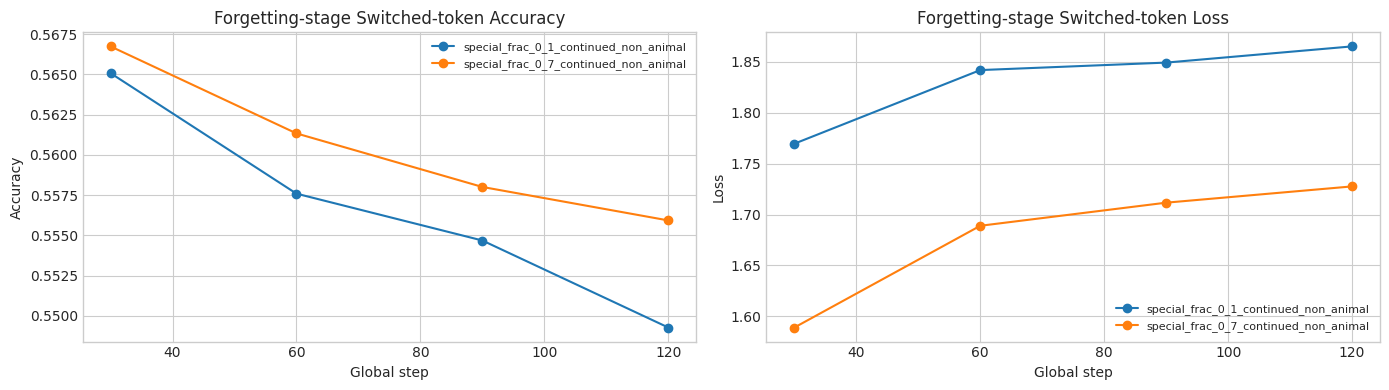

In [42]:
# Forgetting-stage switched-token metrics (continuation runs)
if events_df.empty:
    print("No event history found.")
else:
    ts = events_df[events_df.get("event", "") == "timestep_eval"].copy()
    if ts.empty:
        print("No timestep_eval rows found in history.")
    else:
        run_col = ts.get("run", pd.Series(index=ts.index, dtype=str)).astype(str)
        stage_col = ts.get("stage", pd.Series(index=ts.index, dtype=str)).astype(str).str.lower()

        forgetting_mask = (
            run_col.str.contains("continued_non_animal|forget", case=False, na=False)
            | stage_col.isin(["forgetting", "continuation", "continued_non_animal"])
        )

        forget_ts = ts[forgetting_mask].copy()
        if forget_ts.empty:
            print("No forgetting-stage timestep rows found. (Expected run names like '*continued_non_animal*' or stage='forgetting').")
        else:
            forget_ts["global_step"] = pd.to_numeric(forget_ts["global_step"], errors="coerce")
            forget_ts["switched_acc"] = pd.to_numeric(forget_ts["switched_acc"], errors="coerce")
            forget_ts["switched_loss"] = pd.to_numeric(forget_ts["switched_loss"], errors="coerce")

            display(forget_ts.sort_values(["run", "global_step"]).head(20))

            fig, axes = plt.subplots(1, 2, figsize=(14, 4))

            for run_name, g in forget_ts.groupby("run"):
                g = g.sort_values("global_step")
                axes[0].plot(g["global_step"], g["switched_acc"], marker="o", label=run_name)
                axes[1].plot(g["global_step"], g["switched_loss"], marker="o", label=run_name)

            axes[0].set_title("Forgetting-stage Switched-token Accuracy")
            axes[0].set_xlabel("Global step")
            axes[0].set_ylabel("Accuracy")

            axes[1].set_title("Forgetting-stage Switched-token Loss")
            axes[1].set_xlabel("Global step")
            axes[1].set_ylabel("Loss")

            axes[0].legend(fontsize=8)
            axes[1].legend(fontsize=8)
            plt.tight_layout()
            plt.show()

In [43]:
# Show training-set examples before vs after adaptation (name -> Tim in animal stories)
from datasets import load_dataset
from tinystories_utils import build_name_vocabulary, replace_most_common_name_with_tim

N_EXAMPLES = 8
DATASET_ID = "roneneldan/TinyStories"
SEED = 42

train_full = load_dataset(DATASET_ID, split="train")
name_vocab = build_name_vocabulary(train_full, min_count=1)

print(f"Name vocab size: {len(name_vocab)}")
print(f"Sampling {N_EXAMPLES} adapted examples...\n")

shown = 0
for ex in train_full.shuffle(seed=SEED):
    original = ex["text"]
    adapted, spans = replace_most_common_name_with_tim(original, name_vocab)
    if not spans:
        continue

    shown += 1
    print("=" * 120)
    print(f"Example {shown}")
    print("- ORIGINAL")
    print(original[:900])
    print("\n- ADAPTED")
    print(adapted[:900])
    print(f"\nChanged spans in adapted text: {len(spans)}")

    if shown >= N_EXAMPLES:
        break

if shown == 0:
    print("No adapted examples found with current settings.")

Name vocab size: 15972
Sampling 8 adapted examples...

Example 1
- ORIGINAL
Once upon a time, there was a playful bunny named Benny. Benny loved to hop and play in the meadow with his friends. One day, Benny accidentally bumped into a tree and hurt his leg. 

Benny's friend, a wise owl named Ollie, saw what happened and said, "Benny, you need to go to the doctor to repair your leg." 

Benny didn't want to go to the doctor because he was scared. Ollie winked at him and said, "Don't worry, Benny. The doctor will make you feel better." 

Benny trusted his friend and went to the doctor. The doctor was kind and gentle, and Benny's leg was soon repaired. Benny was so happy and grateful to Ollie for his help.

- ADAPTED
Once upon a time, there was a playful bunny named Tim. Tim loved to hop and play in the meadow with his friends. One day, Tim accidentally bumped into a tree and hurt his leg. 

Tim's friend, a wise owl named Ollie, saw what happened and said, "Tim, you need to go to the docto

In [44]:
# Load trained models and generate sample outputs
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer

if run_summaries_df.empty:
    print("No run summaries found yet, so no models to load.")
else:
    # Collect model dirs from summary, then keep a small subset for quick comparison
    model_paths = []
    for col in ["final_model_path", "continued_model_path"]:
        if col in run_summaries_df.columns:
            model_paths.extend([p for p in run_summaries_df[col].dropna().astype(str).tolist() if p])

    model_paths = sorted(dict.fromkeys(model_paths))
    if not model_paths:
        print("No model paths found in run summary.")
    else:
        # Keep this small for faster notebook iteration
        MAX_MODELS = 4
        selected_model_paths = model_paths[:MAX_MODELS]

        prompts = [
            "Laura saw a lion in the garden and",
            "Max and the dog walked to the river where",
            "Tom told the rabbit that",
            "At school, Mia learned that the fish",
            "Max was at home"
        ]

        max_new_tokens = 200
        temperature = 0.8
        top_p = 0.95

        device = "cuda" if torch.cuda.is_available() else "cpu"
        print(f"Using device: {device}")
        print("Selected models:")
        for mp in selected_model_paths:
            print(" -", mp)

        for model_path_str in selected_model_paths:
            model_path = Path(model_path_str)
            if not model_path.exists():
                print(f"Skipping missing model path: {model_path}")
                continue

            print("\n" + "=" * 100)
            print(f"MODEL: {model_path}")
            print("=" * 100)

            tokenizer = AutoTokenizer.from_pretrained(str(model_path), use_fast=True)
            if tokenizer.pad_token is None:
                tokenizer.pad_token = tokenizer.eos_token

            model = AutoModelForCausalLM.from_pretrained(str(model_path)).to(device)
            model.eval()

            for i, prompt in enumerate(prompts, start=1):
                inputs = tokenizer(prompt, return_tensors="pt").to(device)
                with torch.no_grad():
                    out_ids = model.generate(
                        **inputs,
                        max_new_tokens=max_new_tokens,
                        do_sample=True,
                        temperature=temperature,
                        top_p=top_p,
                        pad_token_id=tokenizer.pad_token_id,
                        eos_token_id=tokenizer.eos_token_id,
                    )
                text = tokenizer.decode(out_ids[0], skip_special_tokens=True)

                print(f"\nPrompt {i}: {prompt}")
                print("Response:")
                print(text)
                print("-" * 100)

            del model
            if torch.cuda.is_available():
                torch.cuda.empty_cache()

Using device: cuda
Selected models:
 - finetune_runs_Tim/special_frac_0_5/final_model
 - finetune_runs_Tim/special_frac_1/final_model

MODEL: finetune_runs_Tim/special_frac_0_5/final_model


Loading weights:   0%|          | 0/108 [00:00<?, ?it/s]


Prompt 1: Laura saw a lion in the garden and
Response:
Laura saw a lion in the garden and wanted to know what it was. It decided to go for a walk and explore. The lion noticed a big tree and decided to take a look.

When the lion arrived, the lion was surprised and wanted to know what was happening. So it flew away. The lion was very proud and happy to have found the best way home.

The lion was so pleased with what it had gone. But then something strange happened. It was a big bear! It had never seen anything like a bear before. The lion was so excited and ran towards the bear.

The bear and the bear were so happy that they found the bear and the bear. They both smiled and thanked the bear for the reward. 

The bear was so happy that it had had been the best adventure! The bear thanked the bear and the bear for leading its way home. From then on, it was a very exciting adventure, and the bear had a great time.

The bear and
------------------------------------------------------------

Loading weights:   0%|          | 0/108 [00:00<?, ?it/s]


Prompt 1: Laura saw a lion in the garden and
Response:
Laura saw a lion in the garden and wanted to find the lion, but it was too big.

Andy decided to climb a tree in and look for the lion's trunk. He was so small that he couldn't find the other animals and the lion was very sad.

Suddenly, the lion started to shake and it started to shake. His trunk and Tim was starting to sad. He was so scared that he couldn't find his trunk.

Then, he saw a big tree in the corner of the jungle. He was so scared! He tried to find a way to find his trunk, but he was too fast.

So he ran back to the tree and started walking. He never saw his owner again and couldn't see him. He kept walking around the fence until the sky went down.

Finally, he finally returned home with a big smile on his face. He was so relieved that he could see his owner again. The lion was very grateful for his help, and he was glad
-------------------------------------------------------------------------------------------------

In [45]:
# Interp setup: compare two finetuned models against pretrained
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from transformers import AutoModelForCausalLM, AutoTokenizer

PRETRAINED_MODEL_ID = "SauravP97/tiny-stories-3M"
COMPARE_MODELS = 2

if run_summaries_df.empty or "final_model_path" not in run_summaries_df.columns:
    raise RuntimeError("Need run_summaries_df with final_model_path. Run earlier summary cells first.")

# Pick two finetuned checkpoints by highest fraction
pick_df = run_summaries_df.sort_values("fraction", ascending=False).head(COMPARE_MODELS)
finetuned_paths = pick_df["final_model_path"].astype(str).tolist()
finetuned_names = [f"finetuned_frac_{f}" for f in pick_df["fraction"].tolist()]

print("Pretrained:", PRETRAINED_MODEL_ID)
print("Finetuned checkpoints:")
for n, p in zip(finetuned_names, finetuned_paths):
    print(" -", n, "=>", p)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

tokenizer = AutoTokenizer.from_pretrained(PRETRAINED_MODEL_ID, use_fast=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

models = {"pretrained": AutoModelForCausalLM.from_pretrained(PRETRAINED_MODEL_ID).to(device).eval()}
for name, path in zip(finetuned_names, finetuned_paths):
    models[name] = AutoModelForCausalLM.from_pretrained(path).to(device).eval()

print("Loaded models:", list(models.keys()))

Pretrained: SauravP97/tiny-stories-3M
Finetuned checkpoints:
 - finetuned_frac_1.0 => finetune_runs_Tim/special_frac_1/final_model
 - finetuned_frac_0.5 => finetune_runs_Tim/special_frac_0_5/final_model
Device: cuda


Loading weights:   0%|          | 0/108 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/108 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/108 [00:00<?, ?it/s]

Loaded models: ['pretrained', 'finetuned_frac_1.0', 'finetuned_frac_0.5']


,model,layer,rel_l2_delta,num_params
0,finetuned_frac_1.0,0,0.165828,49792
1,finetuned_frac_1.0,1,0.159595,49792
2,finetuned_frac_1.0,2,0.151158,49792
3,finetuned_frac_1.0,3,0.152650,49792
4,finetuned_frac_1.0,4,0.148413,49792


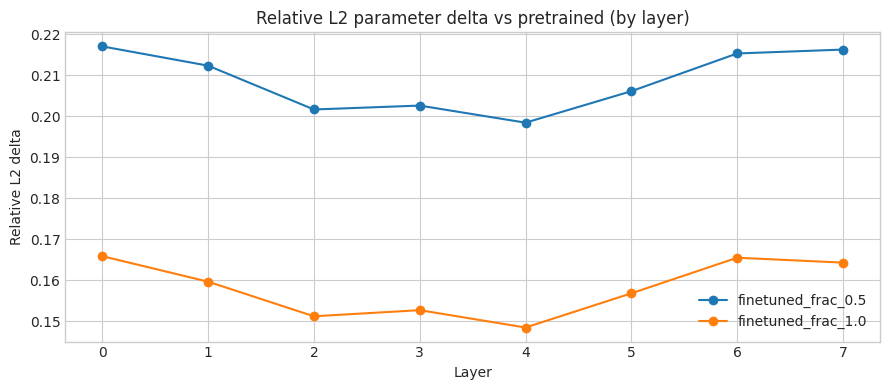

In [46]:
# Interp 1: layer-wise parameter delta vs pretrained (robust key matching)
pre_sd = models["pretrained"].state_dict()

# Infer number of layers from config
cfg = models["pretrained"].config
n_layers = getattr(cfg, "num_layers", None) or getattr(cfg, "n_layer", None)
if n_layers is None:
    raise RuntimeError("Could not infer number of layers from model config.")

# Infer actual layer key prefix style from state_dict
if any(k.startswith("transformer.h.0.") for k in pre_sd.keys()):
    layer_prefix_template = "transformer.h.{i}."
elif any(k.startswith("gpt_neox.layers.0.") for k in pre_sd.keys()):
    layer_prefix_template = "gpt_neox.layers.{i}."
elif any(k.startswith("model.layers.0.") for k in pre_sd.keys()):
    layer_prefix_template = "model.layers.{i}."
else:
    sample_keys = list(pre_sd.keys())[:20]
    raise RuntimeError(
        "Unknown layer prefix format in state_dict. Sample keys: " + str(sample_keys)
    )

rows = []
for model_name, model in models.items():
    if model_name == "pretrained":
        continue
    sd = model.state_dict()

    for layer_idx in range(int(n_layers)):
        layer_prefix = layer_prefix_template.format(i=layer_idx)
        delta_sq = 0.0
        base_sq = 0.0
        count = 0

        for key, pre_t in pre_sd.items():
            if not key.startswith(layer_prefix):
                continue
            if key not in sd:
                continue
            cur_t = sd[key]
            diff = (cur_t - pre_t).float()
            delta_sq += float((diff * diff).sum().item())
            base_sq += float((pre_t.float() * pre_t.float()).sum().item())
            count += pre_t.numel()

        rel_l2 = (delta_sq ** 0.5) / ((base_sq ** 0.5) + 1e-12) if count > 0 else float("nan")
        rows.append({
            "model": model_name,
            "layer": layer_idx,
            "rel_l2_delta": rel_l2,
            "num_params": count,
        })

param_delta_df = pd.DataFrame(rows)
display(param_delta_df.head())

fig, ax = plt.subplots(figsize=(9, 4))
for model_name, g in param_delta_df.groupby("model"):
    g = g.sort_values("layer")
    ax.plot(g["layer"], g["rel_l2_delta"], marker="o", label=model_name)
ax.set_title("Relative L2 parameter delta vs pretrained (by layer)")
ax.set_xlabel("Layer")
ax.set_ylabel("Relative L2 delta")
ax.legend()
plt.tight_layout()
plt.show()

Using fallback tokenizer for interp: EleutherAI/gpt-neo-125M
finetuned_frac_1.0: mean KL(pretrained || model) at last token = 1.023811
finetuned_frac_0.5: mean KL(pretrained || model) at last token = 1.030766


,model,layer,cosine_last_token,l2_last_token
0,finetuned_frac_1.0,0,0.983477,0.511126
1,finetuned_frac_1.0,1,0.922426,2.682421
2,finetuned_frac_1.0,2,0.966638,4.823161
3,finetuned_frac_1.0,3,0.970505,5.471555
4,finetuned_frac_1.0,4,0.965647,6.115373


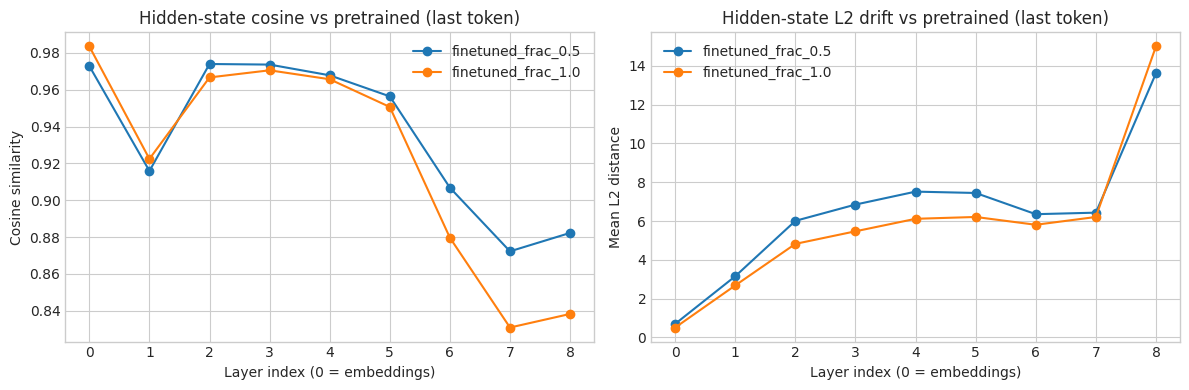

In [47]:
# Interp 2: layer-wise hidden-state drift and output KL vs pretrained
from transformers import AutoTokenizer

probe_prompts = [
    "Laura saw a lion in the garden and",
    "Max and the dog walked to the river where",
    "Tim told the rabbit that",
    "At school, Mia learned that",
    "The cat and the boy were playing when",
    "One day, a tiger and a child",
]

# Robust tokenizer fallback (some model tokenizers can return 0-length encodings)
analysis_tokenizer = tokenizer
probe_test = analysis_tokenizer("hello world", return_tensors="pt")["input_ids"]
if probe_test.shape[1] == 0:
    analysis_tokenizer = AutoTokenizer.from_pretrained("EleutherAI/gpt-neo-125M", use_fast=True)
    if analysis_tokenizer.pad_token is None:
        analysis_tokenizer.pad_token = analysis_tokenizer.eos_token
    print("Using fallback tokenizer for interp: EleutherAI/gpt-neo-125M")

inputs = analysis_tokenizer(
    probe_prompts,
    return_tensors="pt",
    padding=True,
    truncation=True,
    max_length=128,
).to(device)

if inputs["input_ids"].shape[1] == 0:
    raise RuntimeError("Tokenization produced zero-length inputs; cannot run interp metrics.")

with torch.no_grad():
    out_pre = models["pretrained"](**inputs, output_hidden_states=True)
    hs_pre = out_pre.hidden_states
    logits_pre = out_pre.logits

rows = []
for model_name, model in models.items():
    if model_name == "pretrained":
        continue

    with torch.no_grad():
        out_cur = model(**inputs, output_hidden_states=True)
        hs_cur = out_cur.hidden_states
        logits_cur = out_cur.logits

    # Hidden-state cosine by layer (last-token pooled over batch)
    for layer_idx in range(len(hs_pre)):
        pre_vec = hs_pre[layer_idx][:, -1, :].float()
        cur_vec = hs_cur[layer_idx][:, -1, :].float()
        cos = torch.nn.functional.cosine_similarity(pre_vec, cur_vec, dim=-1).mean().item()
        l2 = torch.norm(cur_vec - pre_vec, dim=-1).mean().item()
        rows.append({
            "model": model_name,
            "layer": layer_idx,
            "cosine_last_token": cos,
            "l2_last_token": l2,
        })

    # KL divergence on next-token distribution at last position
    pre_last = logits_pre[:, -1, :].float()
    cur_last = logits_cur[:, -1, :].float()
    p = torch.softmax(pre_last, dim=-1)
    q = torch.softmax(cur_last, dim=-1)
    kl = (p * (torch.log(p + 1e-12) - torch.log(q + 1e-12))).sum(dim=-1).mean().item()
    print(f"{model_name}: mean KL(pretrained || model) at last token = {kl:.6f}")

hidden_df = pd.DataFrame(rows)
display(hidden_df.head())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for model_name, g in hidden_df.groupby("model"):
    g = g.sort_values("layer")
    axes[0].plot(g["layer"], g["cosine_last_token"], marker="o", label=model_name)
    axes[1].plot(g["layer"], g["l2_last_token"], marker="o", label=model_name)

axes[0].set_title("Hidden-state cosine vs pretrained (last token)")
axes[0].set_xlabel("Layer index (0 = embeddings)")
axes[0].set_ylabel("Cosine similarity")

axes[1].set_title("Hidden-state L2 drift vs pretrained (last token)")
axes[1].set_xlabel("Layer index (0 = embeddings)")
axes[1].set_ylabel("Mean L2 distance")

axes[0].legend()
axes[1].legend()
plt.tight_layout()
plt.show()

In [50]:
# Diagnose switched-token metric on pretrained: what is being scored?
import torch
from collections import Counter

# Reuse objects from Cell 11 when available
if "eval_pairs" not in globals() or len(eval_pairs) == 0:
    raise RuntimeError("Run Cell 11 first to build eval_pairs.")
if "fast_tok" not in globals():
    raise RuntimeError("Run Cell 11 first to initialize fast_tok.")
if "model" not in globals():
    raise RuntimeError("Run Cell 11 first to initialize pretrained model.")

device = "cuda" if torch.cuda.is_available() else "cpu"
model.eval()

token_counter = Counter()
tim_token_count = 0
total_scored_tokens = 0
correct = 0

for flipped_text, switched_spans in eval_pairs:
    enc = fast_tok(
        flipped_text,
        return_tensors="pt",
        truncation=True,
        max_length=cfg.max_length,
        add_special_tokens=False,
        return_offsets_mapping=True,
    )
    ids = enc["input_ids"]
    offsets = enc["offset_mapping"][0]
    if ids.shape[1] < 2:
        continue
    ids = ids.to(device)

    with torch.no_grad():
        out = model(input_ids=ids)
        logits = out.logits[:, :-1, :]
        labels = ids[:, 1:]
        preds = torch.argmax(logits, dim=-1)

    for j in range(labels.shape[1]):
        token_span = tuple(int(x) for x in offsets[j + 1].tolist())
        if token_span[0] == token_span[1]:
            continue
        if any((token_span[0] < sw[1] and sw[0] < token_span[1]) for sw in switched_spans):
            token_id = int(labels[0, j].item())
            tok = fast_tok.decode([token_id])
            token_counter[tok] += 1
            total_scored_tokens += 1
            if tok.strip().lower() == "tim":
                tim_token_count += 1
            correct += int((preds[0, j] == labels[0, j]).item())

diag_acc = correct / max(total_scored_tokens, 1)
print("=== Switched-token diagnostic ===")
print("Eval pairs:", len(eval_pairs))
print("Scored switched tokens:", total_scored_tokens)
print("Computed accuracy from raw loop:", round(diag_acc, 6))
if "metrics" in globals():
    print("Cell 11 reported accuracy:", round(float(metrics["acc"]), 6))
print("Fraction of scored tokens that are 'Tim':", round(tim_token_count / max(total_scored_tokens, 1), 6))

print("\nTop switched target tokens:")
for tok, c in token_counter.most_common(15):
    print(f"{repr(tok):>12} : {c}")

=== Switched-token diagnostic ===
Eval pairs: 500
Scored switched tokens: 2265
Computed accuracy from raw loop: 0.31479
Cell 11 reported accuracy: 0.31479
Fraction of scored tokens that are 'Tim': 1.0

Top switched target tokens:
      ' Tim' : 1858
       'Tim' : 407


In [51]:
# Qualitative check: ground-truth vs pretrained predictions on switched examples
import torch

if "eval_pairs" not in globals() or len(eval_pairs) == 0:
    raise RuntimeError("Run Cell 11 first to build eval_pairs.")
if "model" not in globals():
    raise RuntimeError("Run Cell 11 first to load pretrained model.")
if "analysis_tokenizer" not in globals() and "tokenizer" not in globals():
    raise RuntimeError("Need tokenizer in memory. Run prior model cells first.")

tok = analysis_tokenizer if "analysis_tokenizer" in globals() else tokenizer
if tok.pad_token is None:
    tok.pad_token = tok.eos_token

model.eval()
device = "cuda" if torch.cuda.is_available() else "cpu"

N_SHOW = 5
MAX_NEW_TOKENS = 50
MIN_PROMPT_CHARS = 20

shown = 0
for flipped_text, switched_spans in eval_pairs:
    if not switched_spans:
        continue

    first_start = int(switched_spans[0][0])
    prompt = flipped_text[:first_start].strip()
    if len(prompt) < MIN_PROMPT_CHARS:
        continue

    # Ground-truth continuation from adapted text
    gt_cont = flipped_text[first_start:first_start + 220]

    inputs = tok(prompt, return_tensors="pt").to(device)
    if inputs["input_ids"].shape[1] == 0:
        continue

    with torch.no_grad():
        out_ids = model.generate(
            **inputs,
            max_new_tokens=MAX_NEW_TOKENS,
            do_sample=False,
            pad_token_id=tok.pad_token_id,
            eos_token_id=tok.eos_token_id,
        )

    pred_full = tok.decode(out_ids[0], skip_special_tokens=True)
    pred_cont = pred_full[len(prompt):len(prompt) + 220]

    shown += 1
    print("=" * 120)
    print(f"Example {shown}")
    print("PROMPT:")
    print(prompt[-240:])
    print("\nGROUND TRUTH CONTINUATION (adapted):")
    print(gt_cont)
    print("\nPRETRAINED CONTINUATION (greedy):")
    print(pred_cont)

    if shown >= N_SHOW:
        break

if shown == 0:
    print("No suitable examples found with current constraints.")

Example 1
PROMPT:
 to climb it.

Roxy tried to climb the icy hill, but it was very slippery. She tried again and again, but she kept falling down. Roxy was sad. She wanted to climb the icy hill so much. Then, she saw a little bird named Billy. Billy saw that

GROUND TRUTH CONTINUATION (adapted):
Tim was sad and asked, "Why are you sad, Tim?"

Tim told Billy about the icy hill and how she couldn't climb it. Billy said, "I have an idea! Let's find some big leaves to put under your feet. They will help you climb th

PRETRAINED CONTINUATION (greedy):
 he was sad and asked him if he could help.

Rosa said, "Don't worry, I can help you. I can help you. I can help you, but you can still be careful with the bird."

So
Example 2
PROMPT:
Once upon a time, in a small yard, there was a small daisy. The daisy had a name. Her name was Daisy. Daisy was very small, but she was also very happy.

One day, Daisy saw a dog. The dog was big and had a name too. His name was

GROUND TRUTH CONTINUATION (adapt